### **EDA - Matrículas**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o DataFrame tratado para análise exploratória
df_eda = pd.read_parquet('../data/processed/microdados_matriculas_tratados.parquet')

In [2]:
# Visualizar os tipos de dados e informações gerais do DataFrame
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 10034 entries, 0 to 10033
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   categoria_situacao       10034 non-null  str           
 1   cor_raca                 10034 non-null  str           
 2   codigo_ciclo_matricula   10034 non-null  str           
 3   data_fim_previsto_ciclo  10034 non-null  datetime64[us]
 4   data_inicio_ciclo        10034 non-null  datetime64[us]
 5   faixa_etaria             10034 non-null  str           
 6   idade                    10034 non-null  int64         
 7   nome_curso               10034 non-null  str           
 8   renda_familiar           10034 non-null  str           
 9   sexo                     10034 non-null  str           
 10  situacao_matricula       10034 non-null  str           
 11  tipo_curso               10034 non-null  str           
 12  turno                    10034 non-null  st

In [3]:
# Visualizar as primeiras linhas do DataFrame para verificar o conteúdo
df_eda.head(10)

,categoria_situacao,cor_raca,codigo_ciclo_matricula,data_fim_previsto_ciclo,data_inicio_ciclo,faixa_etaria,idade,nome_curso,renda_familiar,sexo,situacao_matricula,tipo_curso,turno,unidade_ensino
0,Em Curso,Parda,802715,2013-07-12,2011-08-01,45 a 49 anos,49,"Licenciatura para a Educação Profissional, Cie...","1<RFP<=1,5",M,Em curso,Licenciatura,Noturno,Campus Simões Filho
1,Evadidos,Preta,805360,2015-03-08,2011-03-10,30 a 34 anos,31,Matemática,Não declarada,F,Abandono,Licenciatura,Noturno,Campus Valença Tento
2,Em Curso,Branca,805366,2015-12-30,2011-02-15,30 a 34 anos,33,Engenharia Mecânica,Não declarada,M,Em curso,Bacharelado,Noturno,Campus Salvador
3,Em Curso,Não declarada,1209276,2017-03-01,2012-03-01,50 a 54 anos,50,Engenharia Elétrica,"2,5<RFP<=3,5",M,Em curso,Bacharelado,Noturno,Campus Paulo Afonso
4,Em Curso,Branca,1209276,2017-03-01,2012-03-01,30 a 34 anos,34,Engenharia Elétrica,"RFP>3,5",M,Em curso,Bacharelado,Noturno,Campus Paulo Afonso
5,Concluintes,Branca,1209283,2017-06-01,2012-06-01,30 a 34 anos,30,Engenharia Elétrica,"RFP>3,5",M,Integralizada,Bacharelado,Noturno,Campus Paulo Afonso
6,Concluintes,Parda,1209717,2016-03-28,2012-03-30,40 a 44 anos,43,Matemática,"0,5<RFP<=1",M,Integralizada,Licenciatura,Noturno,Campus Valença Tento
7,Concluintes,Parda,1251999,2015-12-18,2012-04-23,40 a 44 anos,41,"Licenciatura para a Educação Profissional, Cie...","2,5<RFP<=3,5",M,Integralizada,Licenciatura,Noturno,Campus Simões Filho
8,Concluídos,Não declarada,1254683,2015-12-30,2012-04-27,45 a 49 anos,47,Geografia,Não declarada,M,Concluída,Licenciatura,Noturno,Campus Salvador
9,Em Curso,Não declarada,1254683,2015-12-30,2012-04-27,50 a 54 anos,54,Geografia,Não declarada,M,Em curso,Licenciatura,Noturno,Campus Salvador


In [4]:
# Medidas estatísticas dos atributos numéricos
df_eda.describe()

,data_fim_previsto_ciclo,data_inicio_ciclo,idade
count,10034,10034,10034.000000
mean,2024-10-10 22:57:25.724536,2020-09-24 09:39:04.269483,28.754335
min,2013-07-12 00:00:00,2011-02-15 00:00:00,18.000000
25%,2023-02-01 00:00:00,2019-04-22 00:00:00,22.000000
50%,2024-12-20 00:00:00,2021-02-08 00:00:00,26.000000
75%,2026-07-31 00:00:00,2022-08-08 00:00:00,33.000000
max,2029-12-31 00:00:00,2023-11-01 00:00:00,78.000000
std,NaN,NaN,8.904756


In [5]:
# Detectar valores ausentes
df_eda.isna().sum()

categoria_situacao         0
cor_raca                   0
codigo_ciclo_matricula     0
data_fim_previsto_ciclo    0
data_inicio_ciclo          0
faixa_etaria               0
idade                      0
nome_curso                 0
renda_familiar             0
sexo                       0
situacao_matricula         0
tipo_curso                 0
turno                      0
unidade_ensino             0
dtype: int64

In [18]:
df_eda['cor_raca'].value_counts()
#df_eda['sexo'].value_counts()

cor_raca
Parda            4239
Branca           2810
Preta            1900
Não declarada     881
Indígena          135
Amarela            69
Name: count, dtype: int64

In [19]:
df_eda['cor_raca'].value_counts(normalize=True).mul(100).round(1)

cor_raca
Parda            42.2
Branca           28.0
Preta            18.9
Não declarada     8.8
Indígena          1.3
Amarela           0.7
Name: proportion, dtype: float64

Evasão por Sexo (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
sexo                                                             
F                      1.640241    4.537999  80.344451  13.477310
M                      2.070263    3.685696  80.599122  13.644918

Evasão por Cor/Raça (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
cor_raca                                                         
Amarela                2.898551    2.898551  81.159420  13.043478
Branca                 2.313167    4.519573  79.572954  13.594306
Indígena               0.740741    0.740741  94.814815   3.703704
Não declarada          1.021566    8.626561  77.639047  12.712826
Parda                  2.170323    3.043171  80.537863  14.248644
Preta                  1.210526    3.473684  82.105263  13.210526

Evasão por Renda Familiar (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
renda_familiar                                                 

<Axes: xlabel='renda_familiar'>

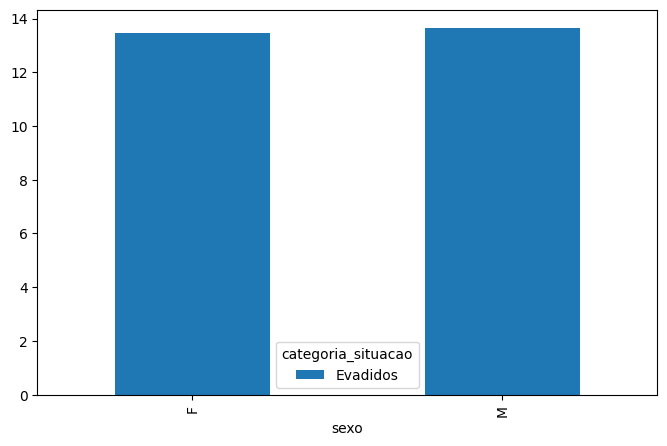

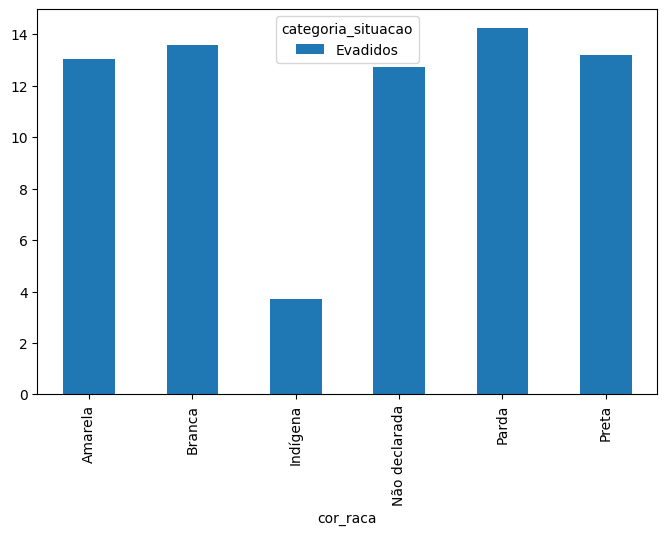

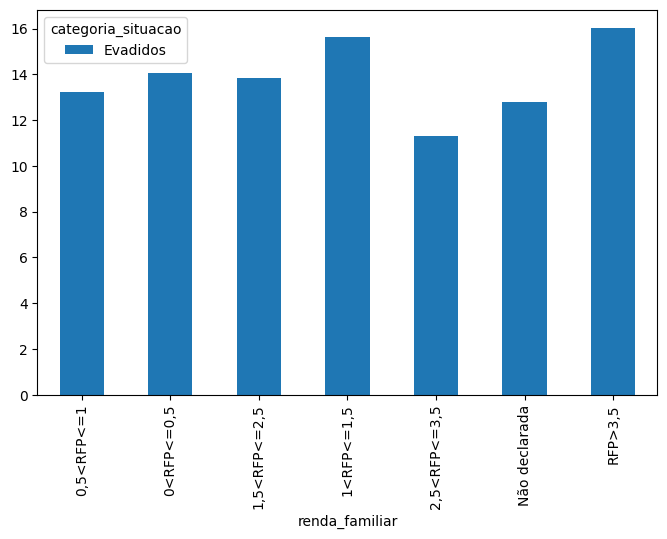

In [7]:
df_eda['sexo'].value_counts()
# Tabela cruzada percentual por Gênero
print("Evasão por Sexo (%):")
crosstab_sexo = pd.crosstab(df_eda['sexo'], df_eda['categoria_situacao'], normalize='index') * 100

print(crosstab_sexo)
crosstab_sexo = crosstab_sexo.drop(columns=['Em Curso'], errors='ignore')
crosstab_sexo = crosstab_sexo.drop(columns=['Concluintes'], errors='ignore')
crosstab_sexo = crosstab_sexo.drop(columns=['Concluídos'], errors='ignore')
# crosstab_sexo = crosstab_sexo.drop(columns=['Evadidos'], errors='ignore')
crosstab_sexo.plot(kind='bar', figsize=(8, 5))

# Tabela cruzada percentual por Cor/Raça
print("\nEvasão por Cor/Raça (%):")
crosstab_cor_raca = pd.crosstab(df_eda['cor_raca'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_cor_raca)
crosstab_cor_raca = crosstab_cor_raca.drop(columns=['Em Curso'], errors='ignore')
crosstab_cor_raca = crosstab_cor_raca.drop(columns=['Concluintes'], errors='ignore')
crosstab_cor_raca = crosstab_cor_raca.drop(columns=['Concluídos'], errors='ignore')
crosstab_cor_raca.plot(kind='bar', figsize=(8, 5))

# Tabela cruzada percentual por Renda Familiar
print("\nEvasão por Renda Familiar (%):")
crosstab_renda_familiar = pd.crosstab(df_eda['renda_familiar'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_renda_familiar)
crosstab_renda_familiar = crosstab_renda_familiar.drop(columns=['Em Curso'], errors='ignore')
crosstab_renda_familiar = crosstab_renda_familiar.drop(columns=['Concluintes'], errors='ignore')
crosstab_renda_familiar = crosstab_renda_familiar.drop(columns=['Concluídos'], errors='ignore')
crosstab_renda_familiar.plot(kind='bar', figsize=(8, 5))


Evasão por Faixa Etária (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
faixa_etaria                                                     
15 a 19 anos           0.000000    0.000000  89.961390  10.038610
20 a 24 anos           1.078776    0.602107  85.750125  12.568991
25 a 29 anos           3.741631    7.798346  74.005514  14.454510
30 a 34 anos           2.400739    7.294552  76.454294  13.850416
35 a 39 anos           1.255708    5.479452  77.511416  15.753425
40 a 44 anos           1.940035    4.056437  79.541446  14.462081
45 a 49 anos           0.583090    4.081633  81.049563  14.285714
50 a 54 anos           1.052632    4.210526  83.684211  11.052632
55 a 59 anos           0.847458    3.389831  82.203390  13.559322
Maior de 60 anos       1.369863    4.109589  76.712329  17.808219


<Axes: xlabel='faixa_etaria'>

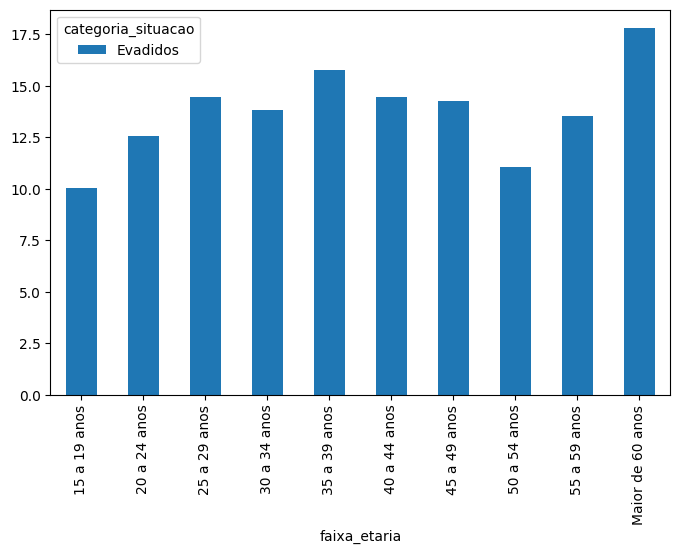

In [8]:

# Tabela cruzada percentual por Faixa Etária
print("\nEvasão por Faixa Etária (%):")

crosstab_faixa_etaria = pd.crosstab(df_eda['faixa_etaria'], df_eda['categoria_situacao'], normalize='index') * 100

print(crosstab_faixa_etaria)
crosstab_faixa_etaria = crosstab_faixa_etaria.drop(columns=['Em Curso'], errors='ignore')
crosstab_faixa_etaria = crosstab_faixa_etaria.drop(columns=['Concluintes'], errors='ignore')
crosstab_faixa_etaria = crosstab_faixa_etaria.drop(columns=['Concluídos'], errors='ignore')
crosstab_faixa_etaria.plot(kind='bar', figsize=(8, 5))


Evasão por Tipo de Curso (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
tipo_curso                                                       
Bacharelado            1.643385    3.944125  84.737058   9.675431
Licenciatura           0.800769    4.708520  77.994875  16.495836
Tecnologia             4.256360    3.033268  74.266145  18.444227

Evasão por Turno (%):
categoria_situacao  Concluintes  Concluídos   Em Curso   Evadidos
turno                                                            
Integral               0.256739    2.182285  86.649551  10.911425
Matutino               0.615385    1.948718  84.923077  12.512821
Noturno                1.952820    4.374317  79.628183  14.044681
Não se aplica          0.593120    2.846975  82.562278  13.997628
Vespertino             5.212355    5.888031  75.482625  13.416988


<Axes: xlabel='turno'>

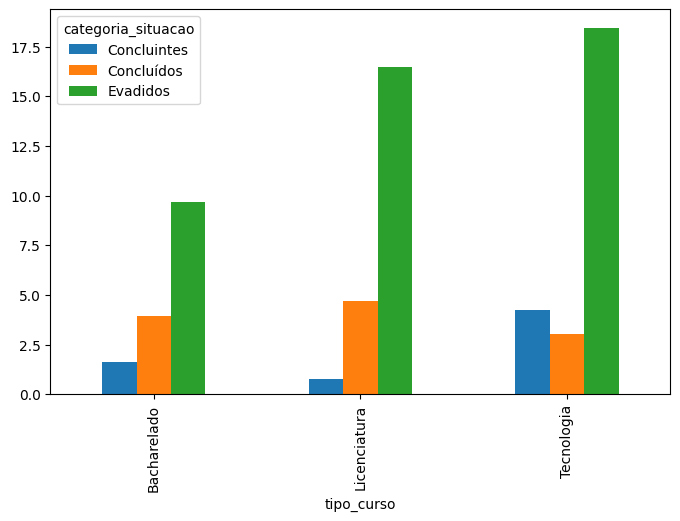

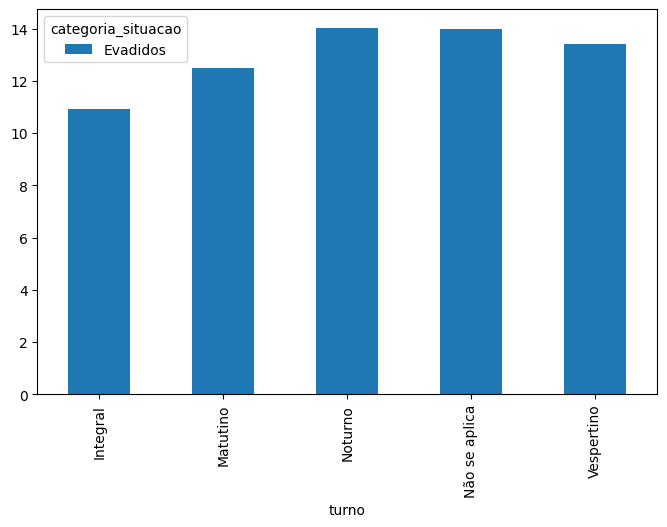

In [9]:
# Tabela cruzada percentual por Tipo de Curso
print("\nEvasão por Tipo de Curso (%):")
crosstab_tipo_curso = pd.crosstab(df_eda['tipo_curso'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_tipo_curso)
crosstab_tipo_curso = crosstab_tipo_curso.drop(columns=['Em Curso'], errors='ignore')
crosstab_tipo_curso.plot(kind='bar', figsize=(8, 5))

# Tabela cruzada percentual por Turno
print("\nEvasão por Turno (%):")
crosstab_turno = pd.crosstab(df_eda['turno'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_turno)
crosstab_turno = crosstab_turno.drop(columns=['Em Curso'], errors='ignore')
crosstab_turno = crosstab_turno.drop(columns=['Concluintes'], errors='ignore')
crosstab_turno = crosstab_turno.drop(columns=['Concluídos'], errors='ignore')
crosstab_turno.plot(kind='bar', figsize=(8, 5))


Evasão por Unidade de Ensino (%):
categoria_situacao             Concluintes  Concluídos    Em Curso   Evadidos
unidade_ensino                                                               
Campus Avançado Ubaitaba          0.000000    0.000000  100.000000   0.000000
Campus Barreiras                  0.000000   10.550459   84.862385   4.587156
Campus Brumado                    0.000000    0.000000   88.275862  11.724138
Campus Camaçari                   0.322581    1.290323   83.548387  14.838710
Campus Eunápolis                  0.000000    5.479452   63.926941  30.593607
Campus Feira de Santana           0.000000    2.298851   97.318008   0.383142
Campus Ilhéus                     0.000000    0.000000   96.741855   3.258145
Campus Irecê                     27.645051    0.682594   53.924915  17.747440
Campus Jacobina                   0.000000    0.000000   88.461538  11.538462
Campus Jequié                     0.000000    0.000000   72.888889  27.111111
Campus Juazeiro              

<Axes: xlabel='unidade_ensino'>

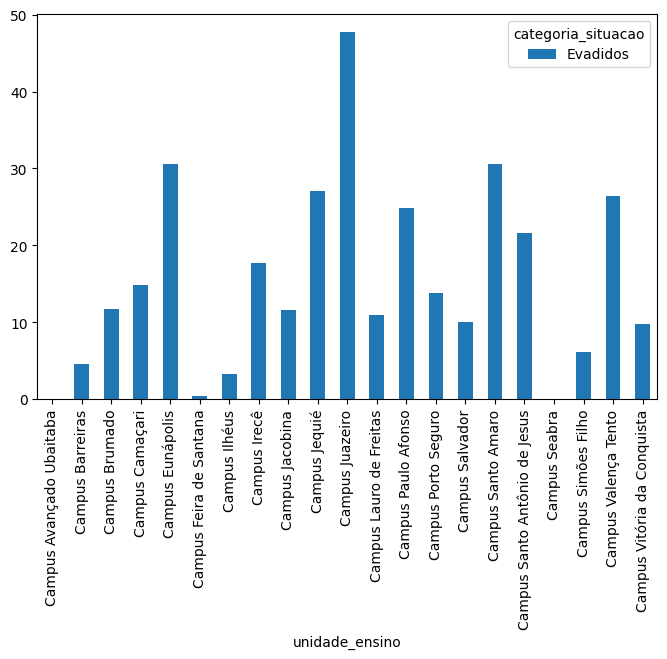

In [10]:
# Tabela cruzada percentual por Unidade de Ensino
print("\nEvasão por Unidade de Ensino (%):")
crosstab_unidade_ensino = pd.crosstab(df_eda['unidade_ensino'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_unidade_ensino)
crosstab_unidade_ensino = crosstab_unidade_ensino.drop(columns=['Em Curso'], errors='ignore')
crosstab_unidade_ensino = crosstab_unidade_ensino.drop(columns=['Concluintes'], errors='ignore')
crosstab_unidade_ensino = crosstab_unidade_ensino.drop(columns=['Concluídos'], errors='ignore')
crosstab_unidade_ensino.plot(kind='bar', figsize=(8, 5))

**Análise de Inconsistência Institucional por Unidade de Ensino**

O cruzamento bivariado entre a localização geográfica (`unidade_ensino`) e o status da matrícula revelou disparidades críticas na distribuição de dados:
1. Efeito de Cursos Recentes: Os campi de Ubaitaba e Seabra apresentam 100% da sua amostra classificada como 'Em Curso'. Essa característica indica que são unidades ou cursos de implementação recente no IFBA, cujas turmas remanescentes ainda não atingiram o tempo de maturação necessário para registrar saídas por conclusão ou abandono.
2. Gargalo Registral e Alerta de Abandono: O Campus Juazeiro apresenta uma taxa de evasão atípica de 47,7%. Este achado correlaciona-se diretamente com o diagnóstico de dados ausentes realizado no tratamento inicial da Engenharia de Dados, onde a mesma unidade liderava a ausência de registros estruturais de vagas, sugerindo inconsistências de preenchimento nos sistemas acadêmicos locais.


In [11]:
# Tabela cruzada percentual por Curso
print("\nEvasão por Curso (%):")
crosstab_curso = pd.crosstab(df_eda['nome_curso'], df_eda['categoria_situacao'], normalize='index') * 100
print(crosstab_curso)


Evasão por Curso (%):
categoria_situacao                                  Concluintes  Concluídos  \
nome_curso                                                                    
Administração                                          0.000000    2.325581   
Agroindústria                                          0.000000    6.422018   
Análise e Desenvolvimento de Sistemas                  6.200787    2.362205   
Arquitetura e Urbanismo                                0.000000   12.500000   
Computação                                             0.000000    4.325033   
Educação Física                                        0.000000    0.000000   
Engenharia Ambiental                                   5.244755    2.447552   
Engenharia Civil                                       5.070423    3.098592   
Engenharia Elétrica                                    2.470930    4.287791   
Engenharia Mecânica                                    0.000000    3.129074   
Engenharia Química           

In [12]:
# Lista com os campi de interesse para a investigação
campi_investigacao = ['Campus Avançado Ubaitaba', 'Campus Seabra', 'Campus Juazeiro']

# Filtrando e agrupando os dados para validar as hipóteses
diagnostico_campi = df_eda[df_eda['unidade_ensino'].isin(campi_investigacao)].groupby(
    'unidade_ensino'
).agg(
    Primeiro_Ingresso=('data_inicio_ciclo', 'min'),
    Ultimo_Ingresso=('data_inicio_ciclo', 'max'),
    Idade_Minima=('idade', 'min'),
    Idade_Maxima=('idade', 'max'),
    Total_Alunos=('codigo_ciclo_matricula', 'count'),
    Cursos_Ofertados=('nome_curso', lambda x: list(x.unique()))
)

# Exibindo o diagnóstico formatado
pd.set_option('display.max_colwidth', None)
display(diagnostico_campi)


,Primeiro_Ingresso,Ultimo_Ingresso,Idade_Minima,Idade_Maxima,Total_Alunos,Cursos_Ofertados
unidade_ensino,,,,,,
Campus Avançado Ubaitaba,2021-09-03,2021-09-20,22,60,62,"[Jogos Digitais, Computação]"
Campus Juazeiro,2021-09-13,2023-10-02,22,65,65,"[Computação, Física]"
Campus Seabra,2021-09-20,2021-09-20,22,52,33,[Computação]


**Validação Temporal e Diagnóstico de Evasão Precoce**

A investigação das coortes temporais dos campi bimodais confirmou as hipóteses iniciais de comportamento dos dados:
1. Maturação Acadêmica (Ubaitaba e Seabra): Com ingresso único em setembro de 2021 para cursos tecnológicos (Computação/Jogos Digitais), as turmas encontravam-se no período regular de integralização em 2023, justificando a taxa de 100% de retenção ativa ('Em Curso') sem registros históricos de conclusão.
2. Vulnerabilidade de Ingresso (Juazeiro): O Campus Juazeiro demonstrou um cenário crítico de evasão precoce. Mesmo com fluxo contínuo de entradas até o final de 2023, a baixa densidade amostral (65 alunos) aliada ao abandono severo nos primeiros períodos dos cursos de Física e Computação inflou o indicador de evasão para 47,7%, evidenciando um forte sinalizador de risco a ser explorado pelo modelo preditivo.

C:\Users\anabz\AppData\Local\Temp\ipykernel_19284\3180716095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y='categoria_situacao', order=df_eda['categoria_situacao'].value_counts().index, palette='viridis');


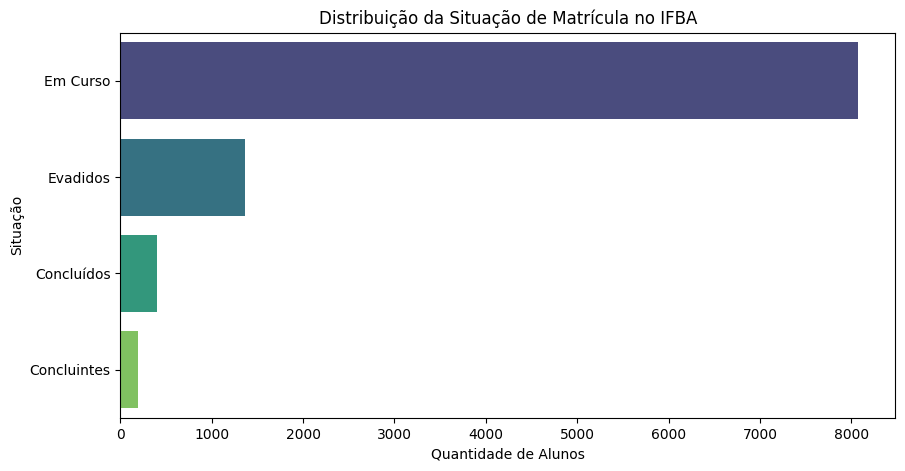

In [ ]:
# Visualizar a distribuição das situações de matrícula
plt.figure(figsize=(10, 5));
sns.countplot(data=df_eda, y='categoria_situacao', order=df_eda['categoria_situacao'].value_counts().index, palette='viridis');
plt.title('Distribuição da Situação de Matrícula no IFBA');
plt.xlabel('Quantidade de Alunos');
plt.ylabel('Situação');
plt.show();

C:\Users\anabz\AppData\Local\Temp\ipykernel_19284\983738303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


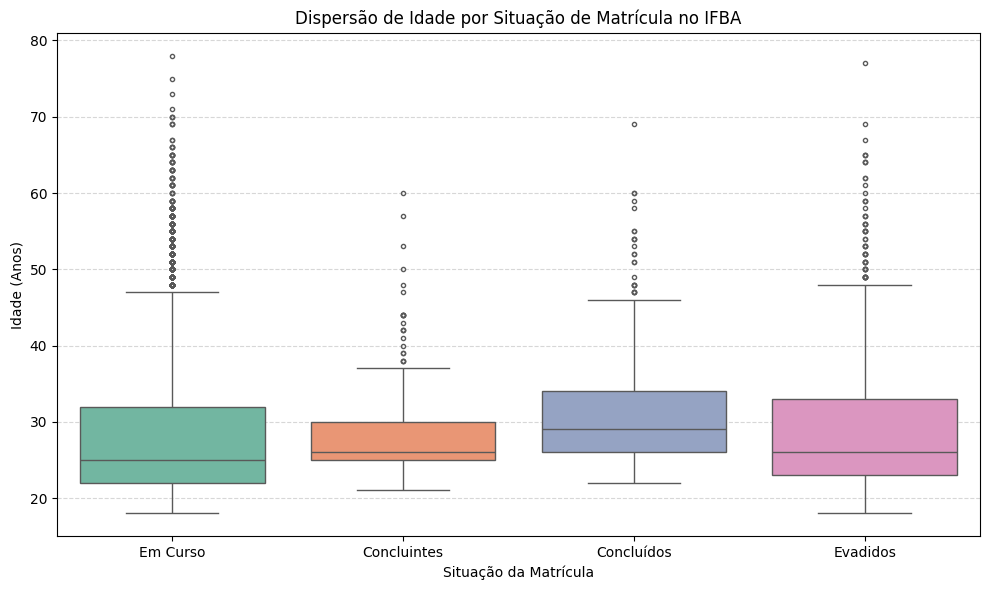

In [14]:
# Definindo uma ordem lógica para facilitar a leitura
ordem_situacao = ['Em Curso', 'Concluintes', 'Concluídos', 'Evadidos']

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_eda, 
    x='categoria_situacao', 
    y='idade', 
    order=ordem_situacao,
    palette='Set2',
    fliersize=3
)

plt.title('Dispersão de Idade por Situação de Matrícula no IFBA')
plt.xlabel('Situação da Matrícula')
plt.ylabel('Idade (Anos)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Evolução da Situação de Matrícula por Ano de Ingresso (Coorte %):


categoria_situacao,Concluintes,Concluídos,Em Curso,Evadidos
ano_ingresso,,,,
2013,12.24,24.49,46.94,16.33
2014,0.81,32.52,52.85,13.82
2015,7.26,20.97,58.06,13.71
2016,4.80,21.19,60.45,13.56
2017,10.28,21.95,48.95,18.82
2018,6.04,10.78,67.54,15.64
2019,2.52,1.54,81.68,14.27
2020,0.54,0.07,89.61,9.78
2021,0.00,0.00,85.97,14.03


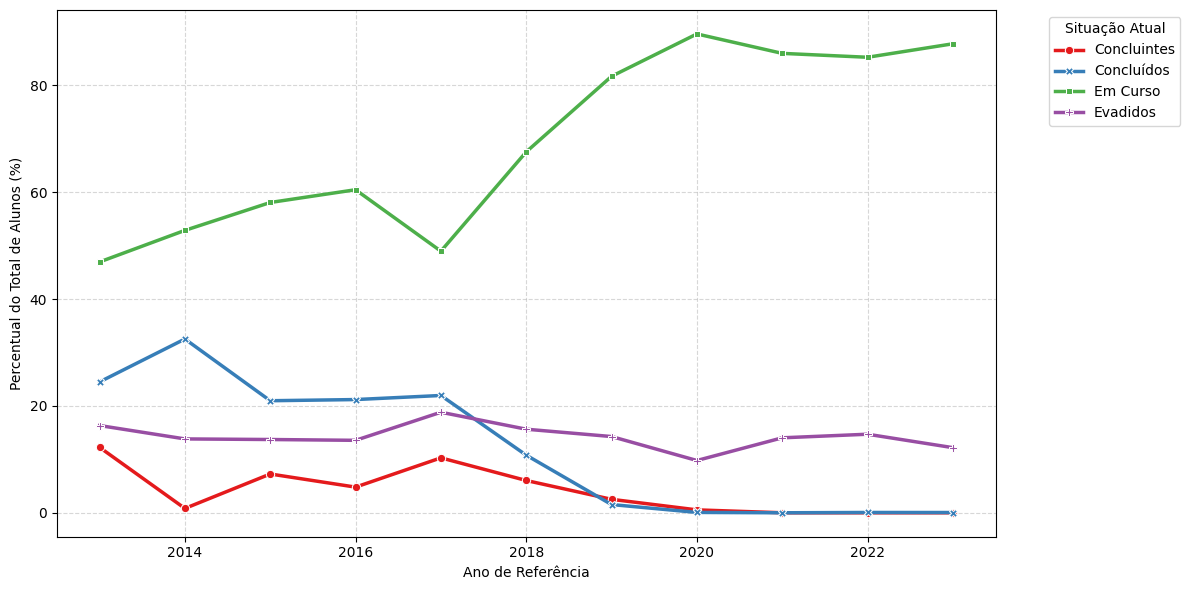

In [15]:
# Garantir o formato datetime e extrair o ano de ingresso
df_eda['data_inicio_ciclo'] = pd.to_datetime(df_eda['data_inicio_ciclo'], errors='coerce')
df_eda['ano_ingresso'] = df_eda['data_inicio_ciclo'].dt.year

# Filtrar uma janela histórica representativa (ex: de 2017 a 2023)
df_temporal = df_eda[(df_eda['ano_ingresso'] >= 2013) & (df_eda['ano_ingresso'] <= 2023)].copy()

# Gerar a tabela cruzada percentual normalizada por ano de ingresso
crosstab_temporal = pd.crosstab(
    df_temporal['ano_ingresso'], 
    df_temporal['categoria_situacao'], 
    normalize='index'
) * 100

print("Evolução da Situação de Matrícula por Ano de Ingresso (Coorte %):")
display(crosstab_temporal.round(2))

# Plotar o gráfico de linhas para analisar as tendências históricas
plt.figure(figsize=(12, 6))
sns.lineplot(data=crosstab_temporal, markers=True, dashes=False, linewidth=2.5, palette='Set1')
#plt.title('Evolução do Status de Matrícula por Coorte de Ingresso no IFBA')
plt.xlabel('Ano de Referência')
plt.ylabel('Percentual do Total de Alunos (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Situação Atual', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# Quantidade de ciclos de matrícula por ano (contagens absolutas)
contagem_por_ano = pd.crosstab(
    df_temporal['ano_ingresso'],
    df_temporal['categoria_situacao'],
    margins=True,
    margins_name='Total'
)

print("Quantidade de ciclos de matrícula por ano:")
display(contagem_por_ano)


Quantidade de ciclos de matrícula por ano:


categoria_situacao,Concluintes,Concluídos,Em Curso,Evadidos,Total
ano_ingresso,,,,,
2013,6,12,23,8,49
2014,1,40,65,17,123
2015,9,26,72,17,124
2016,17,75,214,48,354
2017,59,126,281,108,574
2018,51,91,570,132,844
2019,36,22,1168,204,1430
2020,8,1,1319,144,1472
2021,0,0,1103,180,1283
